# GMM Clustering on Iris Dataset with EM Algorithm

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score

In [2]:
# Load Iris dataset
iris = load_iris()
X = iris.data
y_true = iris.target
print("Dataset shape:", X.shape)

Dataset shape: (150, 4)


In [3]:
# Apply GMM with EM algorithm
gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(X)
y_pred = gmm.predict(X)

In [4]:
# Evaluation Parameters
silhouette = silhouette_score(X, y_pred)
ari = adjusted_rand_score(y_true, y_pred)
bic = gmm.bic(X)
aic = gmm.aic(X)

print("Silhouette Score:", round(silhouette, 4))
print("Adjusted Rand Index:", round(ari, 4))
print("BIC:", round(bic, 4))
print("AIC:", round(aic, 4))

Silhouette Score: 0.5012
Adjusted Rand Index: 0.9039
BIC: 580.8613
AIC: 448.3933


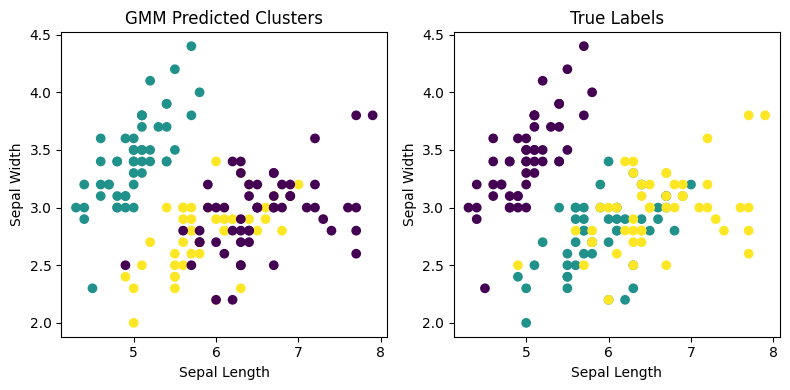

In [5]:
# Plot clusters (using first 2 features)
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis')
plt.title('GMM Predicted Clusters')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')

plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis')
plt.title('True Labels')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.tight_layout()
plt.show()

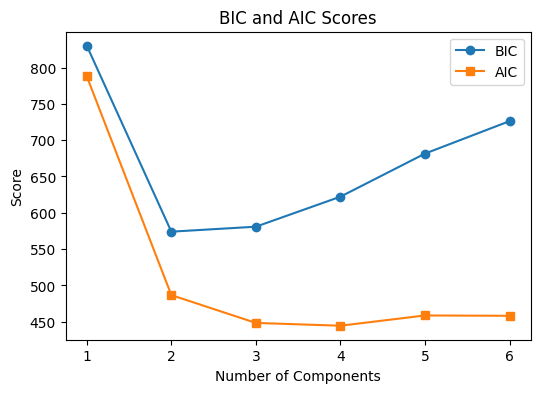

In [6]:
# BIC/AIC for different number of components
n_components_range = range(1, 7)
bic_scores = []
aic_scores = []

for n in n_components_range:
    gmm_temp = GaussianMixture(n_components=n, random_state=42)
    gmm_temp.fit(X)
    bic_scores.append(gmm_temp.bic(X))
    aic_scores.append(gmm_temp.aic(X))

plt.figure(figsize=(6, 4))
plt.plot(n_components_range, bic_scores, 'o-', label='BIC')
plt.plot(n_components_range, aic_scores, 's-', label='AIC')
plt.xlabel('Number of Components')
plt.ylabel('Score')
plt.title('BIC and AIC Scores')
plt.legend()
plt.show()